
[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


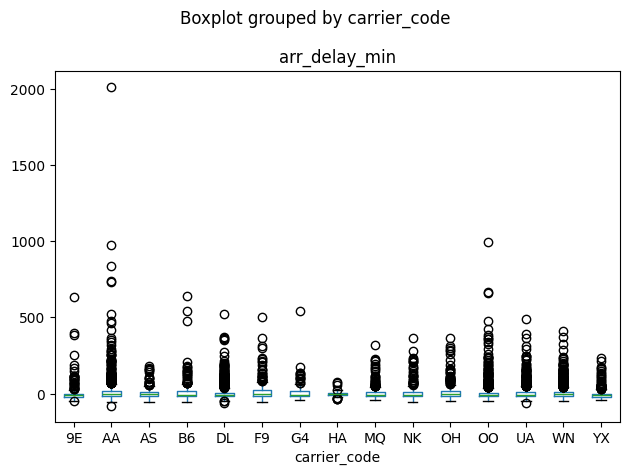

In [24]:
%pip install -q matplotlib

import os
import pandas
import matplotlib.pyplot as plt
%matplotlib inline

project_dir = os.getcwd()
table_path = os.path.join(project_dir, "flightData/flight_data_2024_sample_renamed.csv")

table = pandas.read_csv(table_path, delimiter=',')
table.boxplot(by ='carrier_code', column =['arr_delay_min'], grid = False)
# table.boxplot(by ='day_of_week', column =['arr_delay_min'], grid = False)
# table.boxplot(by ='day_of_month', column =['arr_delay_min'], grid = False)
# table.boxplot(by ='origin_state', column =['arr_delay_min'], grid = False)

# table.boxplot(by ='carrier_code', column =['dep_delay_min'], grid = False)
# table.boxplot(by ='day_of_week', column =['dep_delay_min'], grid = False)
# table.boxplot(by ='day_of_month', column =['dep_delay_min'], grid = False)
# table.boxplot(by ='origin_state', column =['dep_delay_min'], grid = False)

plt.tight_layout()




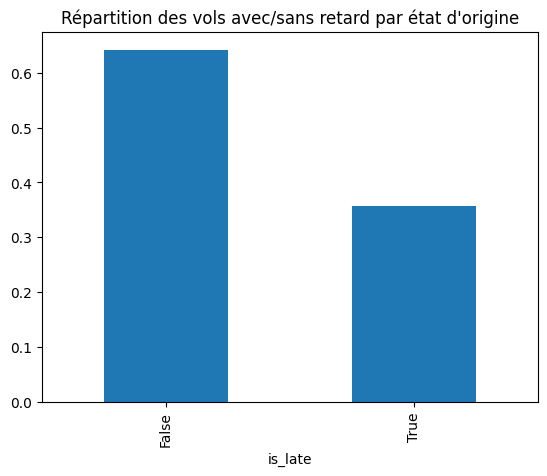

TypeError: no numeric data to plot

In [ ]:
# 1. Graphique général : Répartition globale des retards
barplot = table['is_late'].value_counts(normalize=True).plot.bar(grid=False)
plt.title('Répartition globale des vols avec/sans retard')
plt.ylabel('Proportion')
plt.xlabel('Retard (False=À l\'heure, True=En retard)')
plt.show()

# 2. Analyse par compagnie aérienne : Pourcentage de vols en retard par transporteur
carrier_delay_rate = table.groupby('carrier_code')['is_late'].mean()
carrier_delay_rate.plot.bar(grid=False, figsize=(12, 6))
plt.title('Pourcentage de vols en retard par compagnie aérienne')
plt.ylabel('Proportion de vols en retard')
plt.xlabel('Code transporteur')
plt.xticks(rotation=45)
plt.show()

# 3. Tableau croisé : Répartition détaillée par transporteur
cross_tab = pandas.crosstab(table['carrier_code'], table['is_late'], normalize='index')
cross_tab.plot.bar(stacked=True, grid=False, figsize=(12, 6))
plt.title('Répartition des vols avec/sans retard par transporteur')
plt.ylabel('Proportion')
plt.xlabel('Code transporteur')
plt.legend(['À l\'heure', 'En retard'])
plt.xticks(rotation=45)
plt.show()

# 4. Affichage des statistiques
print("Statistiques de retard par transporteur:")
print(f"{'Transporteur':<12} {'% Retard':<10} {'Total vols':<12}")
print("-" * 35)
for carrier in sorted(table['carrier_code'].unique()):
    carrier_data = table[table['carrier_code'] == carrier]
    pct_late = carrier_data['is_late'].mean() * 100
    total_flights = len(carrier_data)
    print(f"{carrier:<12} {pct_late:<10.1f} {total_flights:<12}")

cross_tab = pandas.crosstab(table['dest_state'], table['is_late'].value_counts(normalize=True))
cross_tab.plot.bar(stacked=True, grid=False)
plt.title('Répartition des vols avec/sans retard par état de destination')
plt.show()

cross_tab = pandas.crosstab(table['carrier_code'], table['is_late'].value_counts(normalize=True))
cross_tab.plot.bar(stacked=True, grid=False)
plt.title('Répartition des vols avec/sans retard météo par transporteur')
plt.show()

